In [20]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from fastai.vision.all import *
import regex as re

In [21]:
path = Path(r'D:\Traffic\traffic_Data\DATA')

In [22]:
path1 = Path(path/'1')

In [23]:
path1.exists()

True

In [24]:
path1 = Path(r'D:\Traffic\traffic_Data\DATA\1')

In [25]:
path1.exists()

True

In [26]:
path1.ls()

[Path('D:/Traffic/traffic_Data/DATA/1/001_0001.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0002.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0003.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0004.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0005.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0006.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0007.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0007_j.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0008.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0009.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0010.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0011.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0012.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0013.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0014.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0015.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0016.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_0017.png'), Path('D:/Traffic/traffic_Data/DATA/1/001_00

In [27]:
fname = path1.ls().sorted()[0]

In [28]:
fname

Path('D:/Traffic/traffic_Data/DATA/1/001_0001.png')

In [29]:
for x in range(58):
    print((path/f'{x}').ls().sorted()[0])

D:\Traffic\traffic_Data\DATA\0\000_0001.png
D:\Traffic\traffic_Data\DATA\1\001_0001.png
D:\Traffic\traffic_Data\DATA\2\002_0001.png
D:\Traffic\traffic_Data\DATA\3\003_0001.png
D:\Traffic\traffic_Data\DATA\4\004_0001.png
D:\Traffic\traffic_Data\DATA\5\005_0001.png
D:\Traffic\traffic_Data\DATA\6\006_0001.png
D:\Traffic\traffic_Data\DATA\7\007_0001.png
D:\Traffic\traffic_Data\DATA\8\008_0001.png
D:\Traffic\traffic_Data\DATA\9\009_0001.png
D:\Traffic\traffic_Data\DATA\10\010_0001.png
D:\Traffic\traffic_Data\DATA\11\011_0001.png
D:\Traffic\traffic_Data\DATA\12\012_0001.png
D:\Traffic\traffic_Data\DATA\13\013_0001.png
D:\Traffic\traffic_Data\DATA\14\014_0001.png
D:\Traffic\traffic_Data\DATA\15\015_0001.png
D:\Traffic\traffic_Data\DATA\16\016_0001.png
D:\Traffic\traffic_Data\DATA\17\017_0001.png
D:\Traffic\traffic_Data\DATA\18\018_0001.png
D:\Traffic\traffic_Data\DATA\19\019_0001.png
D:\Traffic\traffic_Data\DATA\20\020_0001.png
D:\Traffic\traffic_Data\DATA\21\021_0001.png
D:\Traffic\traffic_D

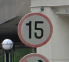

In [30]:
Image.open(fname)

In [32]:
re.findall(r'(\d+)_\d+.png$', str(fname))

['001']

In [33]:
re.findall(r'(\d+)_\d+.png$', fname.name)

['001']

In [34]:
df = pd.read_csv(r'D:\Traffic\labels.csv')

In [35]:
print(df['Name'])

0              Speed limit (5km/h)
1             Speed limit (15km/h)
2             Speed limit (30km/h)
3             Speed limit (40km/h)
4             Speed limit (50km/h)
5             Speed limit (60km/h)
6             Speed limit (70km/h)
7             speed limit (80km/h)
8         Dont Go straight or left
9        Dont Go straight or Right
10                Dont Go straight
11                    Dont Go Left
12           Dont Go Left or Right
13                   Dont Go Right
14         Dont overtake from Left
15                        No Uturn
16                          No Car
17                         No horn
18            Speed limit (40km/h)
19            Speed limit (50km/h)
20            Go straight or right
21                     Go straight
22                         Go Left
23                Go Left or right
24                        Go Right
25                       keep Left
26                      keep Right
27            Roundabout mandatory
28              watc

In [36]:
print(df['Name'][3])

Speed limit (40km/h)


In [ ]:
type(re.findall(r'(\d+)_\d+.png$', fname.name))

list

In [38]:
int(re.findall(r'(\d+)_\d+.png$', fname.name)[0])

1

In [39]:
type(fname)

pathlib.WindowsPath

In [77]:
df

,ClassId,Name
0,0,Speed limit (5km/h)
1,1,Speed limit (15km/h)
2,2,Speed limit (30km/h)
3,3,Speed limit (40km/h)
4,4,Speed limit (50km/h)
5,5,Speed limit (60km/h)
6,6,Speed limit (70km/h)
7,7,speed limit (80km/h)
8,8,Dont Go straight or left
9,9,Dont Go straight or Right


In [91]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return df['Name'][class_id]

In [92]:
label_function(fname)

'Speed limit (15km/h)'

In [93]:
label_function(Path(r'D:\Traffic\traffic_Data\DATA\55\055_1_0002.png'))

'No entry'

In [106]:
signs = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = RandomSplitter(seed = 42),
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [107]:
path = Path(r'D:\Traffic\traffic_Data\DATA')

In [108]:
dataloaders_dict = {}

In [109]:
dls = signs.dataloaders(path)

In [110]:
dls

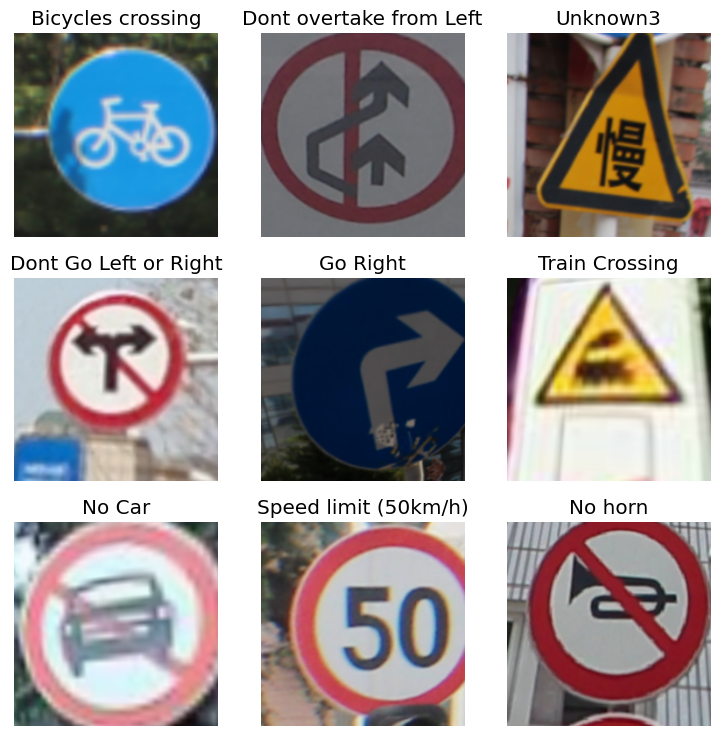

In [112]:
dls.show_batch()

As u can see that the default augentations are mirroring and making left to right and vice versa

so we need to to make custom transforms or edit the datablock

In [113]:
signs.summary(path)

Setting-up type transforms pipelines
Found 4151 items
2 datasets of sizes 3321,830
Setting up Pipeline: PILBase.create
Setting up Pipeline: label_function -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      D:\Traffic\traffic_Data\DATA\38\038_1_0010.png
    applying PILBase.create gives
      PILImage mode=RGB size=109x97
  Pipeline: label_function -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      D:\Traffic\traffic_Data\DATA\38\038_1_0010.png
    applying label_function gives
      Dangerous curve to the left
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(3)

Final sample: (PILImage mode=RGB size=109x97, TensorCategory(3))


Found 4151 items
2 datasets of sizes 3321,830
Setting up Pipeline: PILBase.create
Setting up Pipeline: label_function -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Sett

In [114]:
from fastprogress.fastprogress import master_bar, progress_bar
master_bar, progress_bar = master_bar, progress_bar

In [115]:
baseline_model = vision_learner(dls, arch = resnet34, metrics = error_rate)

In [116]:
baseline_model.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.372283,0.479321,0.131325,01:20


epoch,train_loss,valid_loss,error_rate,time
0,0.363429,0.116527,0.026506,00:40
1,0.169964,0.064300,0.015663,00:49
2,0.073109,0.036253,0.009639,00:44
3,0.034396,0.034484,0.008434,00:46


In [117]:
baseline_model.export('baseline_model.pkl')

In [118]:
x, y = dls.one_batch()

In [119]:
x

TensorImage([[[[-0.1855, -0.1664, -0.1710,  ..., -0.1528, -0.1756, -0.1917],
               [-0.1815, -0.1642, -0.1671,  ..., -0.1500, -0.1759, -0.1935],
               [-0.1806, -0.1701, -0.1727,  ..., -0.1544, -0.1811, -0.1937],
               ...,
               [-0.3872, -0.4006, -0.4013,  ..., -0.2671, -0.2671, -0.2671],
               [-0.3101, -0.3159, -0.3085,  ..., -0.2568, -0.2568, -0.2568],
               [-0.2446, -0.2508, -0.2528,  ..., -0.2568, -0.2568, -0.2568]],

              [[-0.0594, -0.0371, -0.0404,  ..., -0.0106, -0.0340, -0.0505],
               [-0.0547, -0.0335, -0.0374,  ..., -0.0078, -0.0343, -0.0523],
               [-0.0491, -0.0343, -0.0397,  ..., -0.0123, -0.0396, -0.0525],
               ...,
               [-0.4504, -0.4740, -0.4878,  ..., -0.1274, -0.1274, -0.1274],
               [-0.2781, -0.2932, -0.2954,  ..., -0.1170, -0.1170, -0.1170],
               [-0.1498, -0.1645, -0.1666,  ..., -0.1170, -0.1170, -0.1170]],

              [[ 0.1363,  0.1551

In [120]:
y

TensorCategory([ 2, 26, 27, 27, 16, 53, 54, 27,  1, 52,  0, 25, 54, 54, 25, 32, 11, 27, 31, 18, 53, 29, 21, 26, 54,  8, 49,  5,  5, 17, 54, 53, 48, 27, 54, 24,  7, 49,  7, 16, 22, 16, 18, 54, 26, 11,
                22, 46, 18, 52, 19, 52, 54, 35, 35, 32, 54, 27, 32, 49, 11, 53, 44, 34], device='cuda:0')

In [121]:
path_test = Path(r'D:\Traffic\traffic_Data\TEST')

In [148]:
signs_test = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = None,
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [149]:
dls_test = signs_test.dataloaders(path_test)

In [150]:
baseline_model.loss_func

FlattenedLoss of CrossEntropyLoss()

In [151]:
dls_test[0]

In [152]:
len(dls_test[0])

24

In [153]:
len(dls_test[1])

7

In [154]:
len(dls_test[0].dataset)

1596

In [155]:
len(dls_test[1].dataset)

398

Datablock is splitting in by default 80-20 split

In [156]:
for x in dls_test:
    print(f'{x}')

In [157]:
pred_dict = dict()

In [158]:
targ_dict = dict()

In [159]:
print(dls_test[0])

In [160]:
dls_test.train

In [161]:
dls_test.valid

In [166]:
len(dls_test)

2

In [170]:
dls_test.one_batch()

(TensorImage([[[[0.2669, 0.2586, 0.2506,  ..., 0.2294, 0.2288, 0.2288],
                [0.2703, 0.2612, 0.2521,  ..., 0.2299, 0.2292, 0.2288],
                [0.2742, 0.2651, 0.2560,  ..., 0.2318, 0.2317, 0.2314],
                ...,
                [0.2806, 0.2850, 0.2875,  ..., 0.1849, 0.1845, 0.1841],
                [0.2812, 0.2891, 0.2963,  ..., 0.1854, 0.1854, 0.1854],
                [0.2827, 0.2906, 0.2985,  ..., 0.1854, 0.1854, 0.1854]],
 
               [[0.2028, 0.1952, 0.1890,  ..., 0.1444, 0.1437, 0.1437],
                [0.2074, 0.1987, 0.1911,  ..., 0.1450, 0.1442, 0.1437],
                [0.2106, 0.2018, 0.1949,  ..., 0.1470, 0.1468, 0.1466],
                ...,
                [0.3090, 0.3152, 0.3187,  ..., 0.1396, 0.1391, 0.1387],
                [0.3099, 0.3178, 0.3251,  ..., 0.1401, 0.1401, 0.1401],
                [0.3114, 0.3192, 0.3271,  ..., 0.1401, 0.1401, 0.1401]],
 
               [[0.1811, 0.1739, 0.1670,  ..., 0.1263, 0.1256, 0.1256],
                

In [172]:
dls_test.one_batch()[0]

TensorImage([[[[0.6283, 0.6317, 0.6577,  ..., 0.6816, 0.7274, 0.7367],
               [0.6419, 0.6203, 0.6160,  ..., 0.7016, 0.7648, 0.7734],
               [0.6529, 0.6307, 0.6171,  ..., 0.7190, 0.7725, 0.7801],
               ...,
               [0.1667, 0.1794, 0.1862,  ..., 0.9783, 0.9689, 0.9234],
               [0.1649, 0.1766, 0.1853,  ..., 0.9788, 0.9644, 0.9153],
               [0.1654, 0.1736, 0.1819,  ..., 0.9778, 0.9597, 0.9058]],

              [[0.5441, 0.5505, 0.5875,  ..., 0.6291, 0.6793, 0.6874],
               [0.5496, 0.5266, 0.5235,  ..., 0.6513, 0.7249, 0.7382],
               [0.5615, 0.5406, 0.5304,  ..., 0.6648, 0.7362, 0.7552],
               ...,
               [0.1704, 0.1802, 0.1863,  ..., 0.9863, 0.9757, 0.9270],
               [0.1643, 0.1765, 0.1853,  ..., 0.9883, 0.9726, 0.9196],
               [0.1614, 0.1734, 0.1819,  ..., 0.9886, 0.9682, 0.9109]],

              [[0.4632, 0.4653, 0.4937,  ..., 0.5764, 0.6220, 0.6284],
               [0.4671, 0.4432, 0

In [173]:
dls_test.one_batch()[1]

TensorCategory([ 4, 22, 25, 31, 26, 31, 35, 44, 23, 52, 43,  5, 15, 36, 47, 52, 17, 32, 17, 17, 40, 17, 24, 29,  9,  6, 25,  7, 47,  4, 42, 23,  3, 25, 36,  6,  3, 43, 51, 22, 43, 36,  3, 34,  7, 22,
                26, 25, 22, 31,  7,  6,  8, 22, 30, 34, 26,  7, 47,  5, 50, 32, 32, 10], device='cuda:0')

Now we have to check how many values is get_preds function returning

In [185]:
sample = baseline_model.get_preds(dl = dls_test[0],
                                           with_targs = True, 
                                           with_decoded = False, 
                                           with_loss = True, 
                                           save_preds = Path(r'C:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\Traffic_sign\Baseline_model_preds'),
                                           save_targs = Path(r'C:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\Traffic_sign\Baseline_model_targs'),
                                           reorder = False
                                           )

In [186]:
len(sample), type(sample)

(3, tuple)

In [187]:
for i, item in enumerate(sample):
    print(i, type(item), len(item))

0 <class 'torch.Tensor'> 1596
1 <class 'torch.Tensor'> 1596
2 <class 'fastai.torch_core.TensorBase'> 1596


So we haave to make a new dict to store losses as the losses are also returned in this tuple

In [189]:
losses_dict = dict()

In [190]:
for x in range(len(dls_test)):
    dl = dls_test[x]
    pred_dict[x], targ_dict[x], losses_dict[x] = baseline_model.get_preds(dl = dl,
                                           with_targs = True, 
                                           with_decoded = False, 
                                           with_loss = True, 
                                           save_preds = Path(r'C:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\Traffic_sign\Baseline_model_preds'),
                                           save_targs = Path(r'C:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\Traffic_sign\Baseline_model_targs'),
                                           reorder = False
                                           )

In [193]:
pred_dict[0], targ_dict[0], losses_dict[0]

(tensor([[9.1024e-05, 5.2973e-06, 5.3727e-04,  ..., 9.6252e-01, 5.5885e-04, 4.1746e-04],
         [1.2142e-03, 2.4515e-05, 2.9113e-04,  ..., 4.9146e-04, 3.9953e-04, 1.9312e-03],
         [2.4505e-07, 3.1328e-07, 6.9287e-05,  ..., 4.8982e-07, 2.3534e-07, 2.5417e-07],
         ...,
         [2.7637e-03, 4.6704e-04, 1.3404e-03,  ..., 1.9752e-02, 1.2613e-02, 2.2638e-03],
         [1.0476e-06, 1.4924e-08, 3.0266e-08,  ..., 7.8325e-07, 1.8790e-07, 9.7680e-09],
         [9.3612e-04, 6.1613e-05, 3.5670e-04,  ..., 5.5942e-04, 5.2702e-03, 9.8122e-03]]),
 tensor([50, 32, 17,  ..., 26, 26, 25]),
 TensorBase([ 6.5840,  5.5511,  9.4296,  ...,  6.6083, 16.4690,  6.2035]))

In [194]:
def final_loss(losses):
    summation = 0
    total = 0
    for x in range(len(losses)):
        total += len(losses[x])
        for y in range(len(losses[x])):
            summation += losses[x][y]
            
    return float(summation)/float(total)

In [195]:
final_loss(losses_dict)

6.151703646094534